In [2]:
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import torch

CHECKPOINT_PATH = "../Models/vit_crop/checkpoint-32110"

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

Model loaded from ../Models/vit_crop/checkpoint-32110
Using device: mps


In [3]:
def predict_disease(image_path, model, processor, device, top_k=1):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
    
    top_probs, top_indices = torch.topk(probabilities[0], top_k)
    
    results = []
    for prob, idx in zip(top_probs, top_indices):
        label = model.config.id2label[idx.item()]
        results.append({
            'label': label,
            'probability': prob.item(),
            'confidence': f"{prob.item() * 100:.2f}%"
        })
    
    return results


In [5]:
sample_image_path = "../dataset/images/Apple,Grey Spot/plant_84497.jpg"
predictions = predict_disease(sample_image_path, inference_model, inference_processor, device)
for i, pred in enumerate(predictions, 1):
    print(f"{i}. {pred['label']:<40} {pred['confidence']:>10}")

1. Apple,Grey Spot                              99.99%


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        output = self.model(**input_tensor)
        
        if target_class is None:
            target_class = output.logits.argmax(dim=1).item()
        
        self.model.zero_grad()
        
        output.logits[0, target_class].backward()
        
        gradients = self.gradients.cpu().numpy()[0]
        activations = self.activations.cpu().numpy()[0]
        
        weights = np.mean(gradients, axis=0)
        
        cam = np.dot(activations, weights)

        cam = cam[1:]
        
        grid_size = int(np.sqrt(len(cam)))
        if grid_size * grid_size != len(cam):
            print(f"Warning: CAM length ({len(cam)}) is not a perfect square. Reshaping might be incorrect.")
        else:
            cam = cam.reshape(grid_size, grid_size)
        
        cam = np.maximum(cam, 0)
        
        if np.max(cam) > 0:
            cam = cam / np.max(cam)
        
        return cam, target_class


In [7]:
from scipy.ndimage import gaussian_filter 

def visualize_gradcam(image_path, model, processor, device, gradcam, figsize=(15, 5), sigma=1.0):

    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    model.eval()
    cam, predicted_class = gradcam.generate_cam(inputs)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        confidence = probabilities[0, predicted_class].item()
    
    label = model.config.id2label[predicted_class]

    smoothed_cam = gaussian_filter(cam, sigma=sigma)


    cam_resized = cv2.resize(smoothed_cam, (image.width, image.height), interpolation=cv2.INTER_CUBIC)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    

    im = axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    axes[2].imshow(image)
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.5) 
    axes[2].set_title("Overlay", fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%", 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    return cam_resized, label, confidence



In [8]:
target_layer = inference_model.vit.encoder.layer[-1].intermediate.dense

gradcam = GradCAM(inference_model, target_layer)

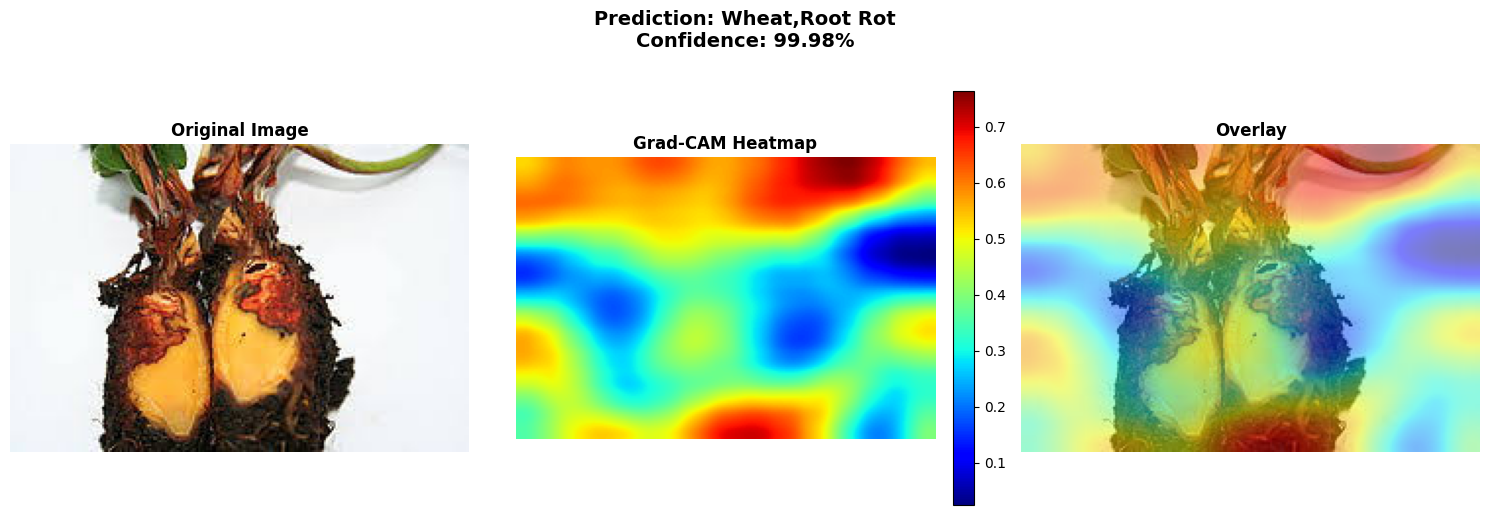

In [10]:
sample_image_path = "../dataset/images/Wheat,Root Rot/plant_130133.jpg"
cam, label, confidence = visualize_gradcam(
    sample_image_path, 
    inference_model, 
    inference_processor, 
    device, 
    gradcam
)